In [969]:
import kidpy3 as kp
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from kidpy3.hardware import Valon5009
from kidpy3.hardware import Transceiver321
from kidpy3.measure import losweep
import importlib

import sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
import time
import os
import scipy.signal # power spectral density fxn.
import datetime
import socket
import glob
from tqdm.notebook import tqdm 

In [970]:
dev = kp.RFSOC("readout.yml")

In [971]:
lo = Valon5009("/dev/IFSLICE_LO")
att = Transceiver321("/dev/IFSLICE_ATTEN")

Checking for baud 115200
Checking for baud 9600
Connected at baud 9600
Connected


In [972]:
dev.rf1.chanmask = np.zeros(1)

In [973]:
dev.upload_bitstream()
dev.config_hardware()

True

## Set your baseband tones here

In [974]:
bb = np.linspace(-245.0e6, 251.0e6, 1000)

dev.set_tone_list(chan=1, tonelist=bb, amplitudes=np.ones_like(bb))
true_bb = dev.get_tone_list(1)

dev.set_tone_list(chan=2, tonelist=bb, amplitudes=np.ones_like(bb))
true_bb = dev.get_tone_list(2)

## Set your Temperature and LO Source Here
1 as in "source 1" which you can see in the open enclosure

In [975]:
# Start here for each temperature. Change the temp, and then proceed to run all code
bath_temperature_reading = '9p90K'

lofreq = 800
dev.rf1.lo_freq = lofreq
lo.set_frequency(1, lofreq)
lo.set_rf_level(1, 10)

b'F 800 MHz; // Act 800 MHz\r\n'


True

## Set your atten here

In [976]:
# RFOUT (DRIVE) Attenuation  ( 0 - 31.75 in 0.25 increments )
att.set_atten(addr=1, value = 5)

(True, 'OK')

In [977]:
# RFIN (SENSE) Attenuation
att.set_atten(addr=2, value = 0)

(True, 'OK')

## Do a sweep


In [ ]:
SYNTH_A = 1
SYNTH_B = 2

def losweep(loSource, channel, f_center, freqs, N_steps=500, freq_step=0.0, naccums=100):
    """
    Actually perform an LO Sweep using valon 5009's and save the data

    :param loSource:
        Valon 5009 Device Object instance
    :type loSource: valon5009.Synthesizer
    :param f_center:
        Center frequency of upconverted tones
    :param freqs: List of Baseband Frequencies returned from rfsocInterface.py's writeWaveform()
    :type freqs: List

    :param udp: udp data capture utility. This is our bread and butter for taking data from ethernet
    :type udp: udpcap.udpcap object instance

    :param N_steps: Number of steps with which to do the sweep.
    :type N_steps: Int

    Credit: Dr. Adrian Sinclair (adriankaisinclair@gmail.com)
    """
    from kidpy3.udp2 import capture_packets
    
    tone_diff = np.diff(freqs)[0] / 1e6  # MHz

    if freq_step > 0:
        flo_step = freq_step
    else:
        flo_step = tone_diff / N_steps

    flo_start = f_center - flo_step * N_steps / 2.0  # 256
    flo_stop = f_center + flo_step * N_steps / 2.0  # 256

    flos = np.arange(flo_start, flo_stop + flo_step, flo_step)  # +1e-6

    actual_los = []

    def temp(lofreq):

        loSource.set_frequency(SYNTH_A, lofreq)
        I, Q = [], []

        # Read values and trash initial read, suspecting linear delay is cause.
        capture_packets(channel, 20)

        for i in range(naccums):
            # d = udp.parse_packet()
            d = capture_packets(channel, 1)[:, 0]
            It = d[::2]
            Qt = d[1::2]
            I.append(It)
            Q.append(Qt)
        I = np.array(I)
        Q = np.array(Q)
        Imed = np.median(I, axis=0)
        Qmed = np.median(Q, axis=0)

        Z = Imed + 1j * Qmed
        Z = Z[8 : 8 + len(freqs)]

        print(".", end="")

        return Z

    sweep_Z = np.array([temp(lofreq) for lofreq in flos])

    f = np.zeros([np.size(freqs), np.size(flos)])

    for itone, ftone in enumerate(freqs):
        f[itone, :] = flos * 1.0e6 + ftone
    sweep_Z_f = sweep_Z.T

    # set the LO back to the original frequency
    loSource.set_frequency(SYNTH_A, f_center)

    return (f, sweep_Z_f)

In [979]:
lofreq = 800
dev.rf1.lo_freq = lofreq
lo.set_frequency(1, lofreq)
lo.set_rf_level(1, 10)

sfreq, s21 = losweep(lo, dev.rf1, dev.rf1.lo_freq, true_bb[0], naccums=10)

b'F 800 MHz; // Act 800 MHz\r\n'
b'F 799.751751 MHz; // Act 799.75175 MHz\r\n'
.b'F 799.752744 MHz; // Act 799.752747 MHz\r\n'
.b'F 799.753737 MHz; // Act 799.753737 MHz\r\n'
.b'F 799.75473 MHz; // Act 799.75473 MHz\r\n'
.b'F 799.755723 MHz; // Act 799.755721 MHz\r\n'
.b'F 799.756716 MHz; // Act 799.756715 MHz\r\n'
.b'F 799.757709 MHz; // Act 799.757709 MHz\r\n'
.b'F 799.758702 MHz; // Act 799.758702 MHz\r\n'
.b'F 799.759695 MHz; // Act 799.759694 MHz\r\n'
.b'F 799.760688 MHz; // Act 799.760688 MHz\r\n'
.b'F 799.761681 MHz; // Act 799.76168 MHz\r\n'
.b'F 799.762674 MHz; // Act 799.762675 MHz\r\n'
.b'F 799.763667 MHz; // Act 799.763667 MHz\r\n'
.b'F 799.76466 MHz; // Act 799.76466 MHz\r\n'
.b'F 799.765653 MHz; // Act 799.765653 MHz\r\n'
.b'F 799.766646 MHz; // Act 799.766645 MHz\r\n'
.b'F 799.767639 MHz; // Act 799.767639 MHz\r\n'
.b'F 799.768632 MHz; // Act 799.76863 MHz\r\n'
.b'F 799.769625 MHz; // Act 799.769624 MHz\r\n'
.b'F 799.770618 MHz; // Act 799.770618 MHz\r\n'
.b'F 799.771611

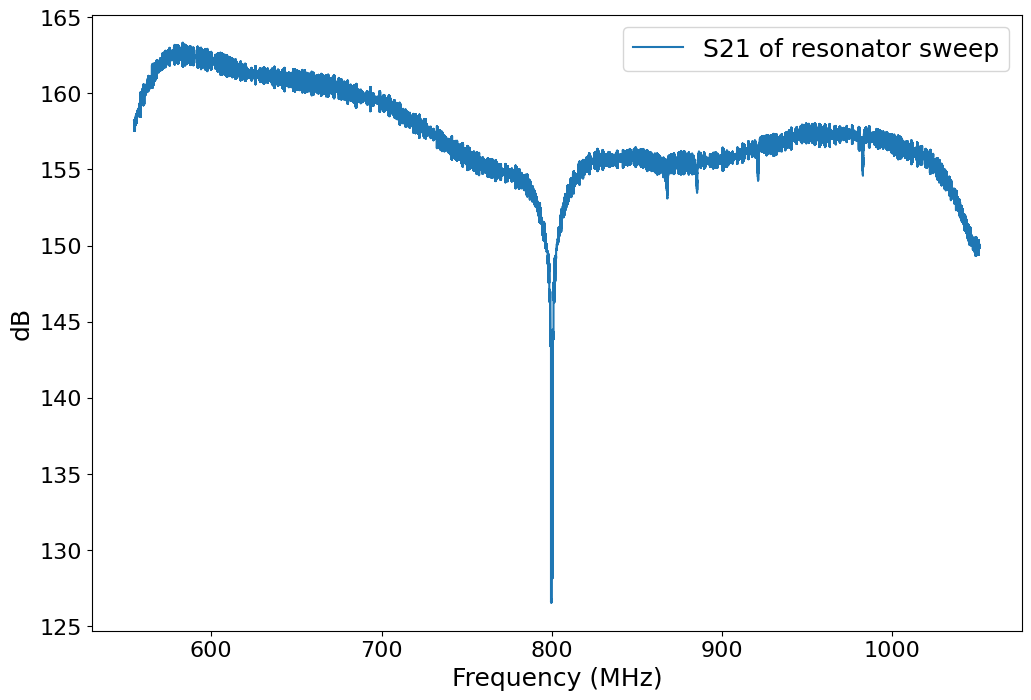

In [980]:
plt.figure(figsize=(12,8))
s21_full = s21.flatten()
s21_sqrd = s21_full.real ** 2 + s21_full.imag ** 2
s21_pow = 10 * np.log10(s21_sqrd)
plt.plot(sfreq.flatten()/1e6, s21_pow)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Frequency (MHz)", fontsize=18)
plt.ylabel("dB", fontsize=18)
plt.legend(["S21 of resonator sweep"], fontsize=18)

path = "/data/TKID_Readout_Plots_12012025/" + bath_temperature_reading
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)
    
filename = path + '/Full_Sweep_' + bath_temperature_reading
plt.savefig(filename)

In [981]:
# Save this sweep for data logging

path = "/data/TKID_Time_Constant_And_Noise_Sweeps_Tones_12012025/" + bath_temperature_reading
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)
    
freqs_filename = path + '/rfsoc_sweep_freqs_' + bath_temperature_reading
s21_filename = path + '/rfsoc_sweep_s21_' + bath_temperature_reading

np.save(freqs_filename, sfreq)
np.save(s21_filename, s21)

In [982]:
# Save results locally
np.save("sweepfreqs", sfreq)
np.save("s21", s21)

## Find Resonators

In [983]:
from kidpy3.measure import ResonatorFinder

In [984]:
loaded_sfreq = np.load("sweepfreqs.npy")
loaded_s21 = np.load("s21.npy")

In [985]:
rfind = ResonatorFinder((loaded_sfreq, loaded_s21), dev.rf1.lo_freq, np.diff(loaded_sfreq.flatten())[0]/1e6)

In [986]:
targfreqs = rfind.find_resonators(6, 1, 1e8)

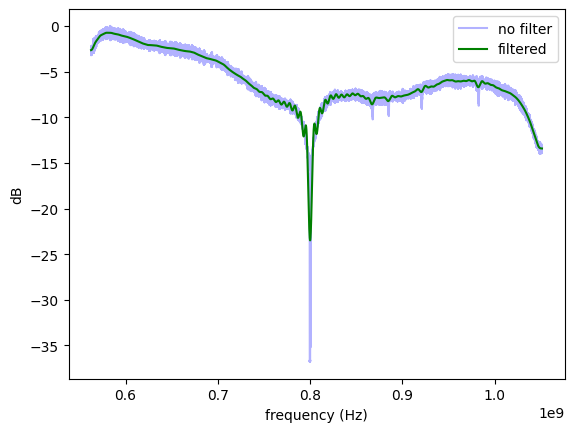

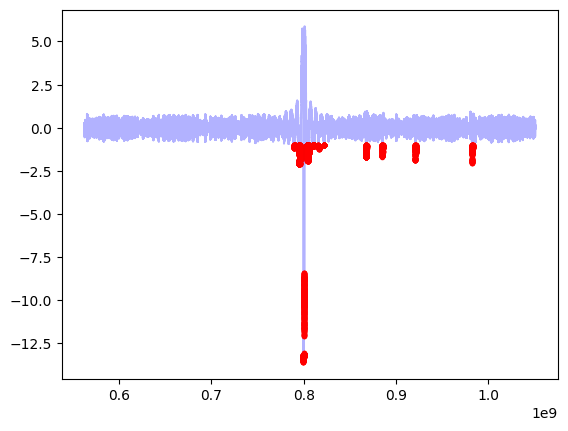

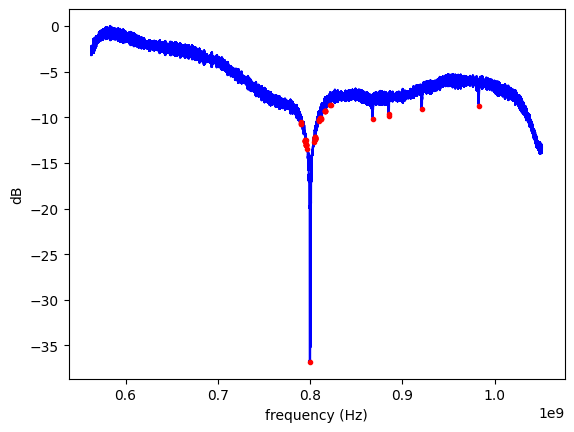

In [987]:
rfind.plot()

In [988]:
import pandas as pdInstructions
upconverted_targfreqs = (targfreqs+lofreq*1e6)
sorted_upconv_targ = (np.sort(upconverted_targfreqs))
sorted_downconv_targ = sorted_upconv_targ - lofreq*1e6

In [989]:
print("\n Baseband target frequencies (Hz): ")
print("\n",targfreqs)
print("\n Sorted upconverted target frequencies (Hz): ")
print("\n",sorted_upconv_targ)
print("\n Sorted baseband target frequencies (Hz): ")
print("\n",sorted_downconv_targ)


 Baseband target frequencies (Hz): 

 [ 4.42990991e+06  5.02570571e+06  5.04457257e+06  5.14188589e+06
  5.16869670e+06  5.22033233e+06  5.23820621e+06  5.26501702e+06
  5.31963163e+06  5.39013413e+06  5.42290290e+06  5.53113914e+06
  5.55596396e+06  5.60958559e+06  9.76526126e+06  9.79107908e+06
  9.83278478e+06  9.90527327e+06  1.11157317e+07  1.12418418e+07
  1.12626947e+07  1.13381622e+07  1.13818539e+07  1.60131732e+07
  1.61651011e+07  1.62028348e+07  1.63299379e+07  1.63497978e+07
  2.20605005e+07  2.21131291e+07  6.78305265e+07  8.53250771e+07
  8.53985586e+07  1.21133397e+08  1.82729746e+08 -1.03954755e+07
 -1.02296456e+07 -9.90592993e+06 -9.83443443e+06 -5.40866466e+06
 -5.35405005e+06 -5.30936537e+06 -5.27361762e+06 -5.25971572e+06
 -5.17630430e+06 -5.14055656e+06 -5.09090691e+06 -4.98763564e+06
 -4.76619820e+06 -4.71456256e+06 -4.66193393e+06 -4.53483083e+06
 -4.49511111e+06 -4.46730731e+06 -4.44744745e+06 -3.72454855e+06
 -4.72496496e+05]

 Sorted upconverted target frequ

In [990]:
# lofreq = 800
dev.rf1.lo_freq = lofreq
lo.set_frequency(1, lofreq)
lo.set_rf_level(1, 10)

# RFOUT (DRIVE) Attenuation  ( 0 - 31.75 in 0.25 increments )
att.set_atten(addr=1, value = 5)

# RFIN (SENSE) Attenuation
att.set_atten(addr=2, value = 5)

# List out the target indices of the four resonant frequencies (usually the last four, though may need manual adjusting)
resonant_frequency_index_list = [len(targfreqs) - 6, len(targfreqs) - 4, len(targfreqs) - 2, len(targfreqs) - 1] # Should correspond to the indices of sorted_upconv_targ that show the RES-1, RES-2, RES-3, RES-4 frequencies respectively

downconv_res_freqs = []
downconv_side_freqs = []

# Add two side frequencies below the LO frequency
upconv_side_freq_a = lofreq*1e6 - 150.0*1e6
upconv_side_freq_b = lofreq*1e6 - 100.0*1e6

downconv_side_freq_a = upconv_side_freq_a - lofreq*1e6
downconv_side_freq_b = upconv_side_freq_b - lofreq*1e6

downconv_side_freqs.append(downconv_side_freq_a)
downconv_side_freqs.append(downconv_side_freq_b)

# Extract the four resonant frequencies (downconverted) and add four side frequencies (downconverted) above the LO frequency near the resonant frequencies
for i, index in enumerate(resonant_frequency_index_list):
    upconv_res_freq_i = sorted_upconv_targ[index]
    downconv_res_freq_i = upconv_res_freq_i - lofreq*1e6
    downconv_res_freqs.append(downconv_res_freq_i)
    
    upconv_side_freq_i = sorted_upconv_targ[index] + 10e6
    downconv_side_freq_i = upconv_side_freq_i - lofreq*1e6
    downconv_side_freqs.append(downconv_side_freq_i)

print("\n Baseband target frequencies (MHz): ")
print("\n",targfreqs/1e6)
print("\n Sorted upconverted target frequencies (MHz): ")
print("\n",sorted_upconv_targ/1e6)
print("\n Sorted baseband target frequencies (MHz): ")
print("\n",sorted_downconv_targ/1e6)

print("\nListed resonant frequencies:\n")
for i, downconv_res_freq in enumerate(downconv_res_freqs):
    upconv_res_freq = downconv_res_freq + lofreq*1e6
    print("%.3f MHz -> (%.3f MHz)\n" %(upconv_res_freq/1e6, downconv_res_freq/1e6))

print("\nListed side frequencies:\n")
for i, downconv_side_freq in enumerate(downconv_side_freqs):
    upconv_side_freq = downconv_side_freq + lofreq*1e6
    print("%.3f MHz -> (%.3f MHz)\n" %(upconv_side_freq/1e6, downconv_side_freq/1e6))

# Combine the two tone lists into a single one
downconv_freqs = downconv_res_freqs + downconv_side_freqs

# Move the active resonant frequency to the be at the front (makes principal component signal cleaning easier later)
downconv_freqs[0], downconv_freqs[1] = downconv_freqs[1], downconv_freqs[0]

print("\n Downconverted frequency list sent to RFSoc (MHz):\n")
print(np.array(downconv_freqs)/1e6)

# 10 tones

dev.set_tone_list(1, downconv_freqs, np.ones_like(downconv_freqs))
true_bb = dev.get_tone_list(1)

dev.set_tone_list(2, downconv_freqs, np.ones_like(downconv_freqs))
true_bb = dev.get_tone_list(2)

# One on-resonance tone test
'''
dev.set_tone_list(1, downconv_freqs[1:2], np.ones_like(downconv_freqs[1:2]))
true_bb = dev.get_tone_list(1)

dev.set_tone_list(2, downconv_freqs[1:2], np.ones_like(downconv_freqs[1:2]))
true_bb = dev.get_tone_list(2)
''';

b'F 800 MHz; // Act 800 MHz\r\n'

 Baseband target frequencies (MHz): 

 [  4.42990991   5.02570571   5.04457257   5.14188589   5.1686967
   5.22033233   5.23820621   5.26501702   5.31963163   5.39013413
   5.4229029    5.53113914   5.55596396   5.60958559   9.76526126
   9.79107908   9.83278478   9.90527327  11.11573173  11.24184184
  11.26269469  11.33816216  11.38185385  16.01317317  16.1651011
  16.20283483  16.32993794  16.3497978   22.0605005   22.11312913
  67.83052653  85.32507708  85.39855856 121.1333974  182.72974575
 -10.39547548 -10.22964565  -9.90592993  -9.83443443  -5.40866466
  -5.35405005  -5.30936537  -5.27361762  -5.25971572  -5.1763043
  -5.14055656  -5.09090691  -4.98763564  -4.7661982   -4.71456256
  -4.66193393  -4.53483083  -4.49511111  -4.46730731  -4.44744745
  -3.72454855  -0.4724965 ]

 Sorted upconverted target frequencies (MHz): 

 [789.60452452 789.77035435 790.09407007 790.16556557 794.59133534
 794.64594995 794.69063463 794.72638238 794.74028428 794.823

In [991]:
def target_sweep(loSource, channel, f_center, target_tones, sweep_freqs):
    """
    Sweeps over a given set of frequencies, you must provide those. 
    Parameters:
        loSource: Valon5009 Instance
        Rfchan: RF channel to work with
        sweep_freqs: Frequnencies that the LO will be set to
        baseband_tones: Tones in baseband used to perform the sweep
    """
    from kidpy3.udp2 import capture_packets

    def temp(lofreq):
        loSource.set_frequency(1, lofreq)
        I, Q = [], []

        # Read values and trash initial read, suspecting linear delay is cause.
        capture_packets(channel, 20)

        for i in range(10):
            d = capture_packets(channel, 1)[:, 0]
            It = d[::2]
            Qt = d[1::2]
            I.append(It)
            Q.append(Qt)
        I = np.array(I)
        Q = np.array(Q)
        Imed = np.median(I, axis=0)
        Qmed = np.median(Q, axis=0)

        Z = Imed + 1j * Qmed
        Z = Z[8 : 8 + len(target_tones)]
        Z = np.array(Z)

        print(".", end="")

        return Z

    sweep_Z = np.array([temp(lofreq) for lofreq in sweep_freqs])

    f = np.zeros([np.size(target_tones), np.size(sweep_freqs)])

    for itone, ftone in enumerate(target_tones):
        f[itone, :] = sweep_freqs * 1.0e6 + ftone
    sweep_Z_f = sweep_Z.T

    # set the LO back to the original frequency
    loSource.set_frequency(1, f_center)

    return (f, sweep_Z_f)

In [992]:
lofreq = 800
dev.rf1.lo_freq = lofreq
lo.set_frequency(1, lofreq)
lo.set_rf_level(1, 10)

loSweepFreqs = np.arange(lofreq - 3, lofreq + 3, 0.15)
target_sweep_freqs, target_sweep_S21 = target_sweep(lo, dev.rf1, dev.rf1.lo_freq, true_bb[0], loSweepFreqs)

b'F 800 MHz; // Act 800 MHz\r\n'
b'F 797 MHz; // Act 797 MHz\r\n'
.b'F 797.15 MHz; // Act 797.15 MHz\r\n'
.b'F 797.3 MHz; // Act 797.3 MHz\r\n'
.b'F 797.449999 MHz; // Act 797.45 MHz\r\n'
.b'F 797.599999 MHz; // Act 797.6 MHz\r\n'
.b'F 797.749999 MHz; // Act 797.75 MHz\r\n'
.b'F 797.899999 MHz; // Act 797.9 MHz\r\n'
.b'F 798.049999 MHz; // Act 798.05 MHz\r\n'
.b'F 798.199999 MHz; // Act 798.2 MHz\r\n'
.b'F 798.349999 MHz; // Act 798.35 MHz\r\n'
.b'F 798.499999 MHz; // Act 798.5 MHz\r\n'
.b'F 798.649999 MHz; // Act 798.65 MHz\r\n'
.b'F 798.799999 MHz; // Act 798.8 MHz\r\n'
.b'F 798.949999 MHz; // Act 798.95 MHz\r\n'
.b'F 799.099999 MHz; // Act 799.1 MHz\r\n'
.b'F 799.249999 MHz; // Act 799.25 MHz\r\n'
.b'F 799.399999 MHz; // Act 799.4 MHz\r\n'
.b'F 799.549999 MHz; // Act 799.55 MHz\r\n'
.b'F 799.699999 MHz; // Act 799.7 MHz\r\n'
.b'F 799.849999 MHz; // Act 799.85 MHz\r\n'
.b'F 799.999999 MHz; // Act 800 MHz\r\n'
.b'F 800.149999 MHz; // Act 800.15 MHz\r\n'
.b'F 800.299999 MHz; // Act 800

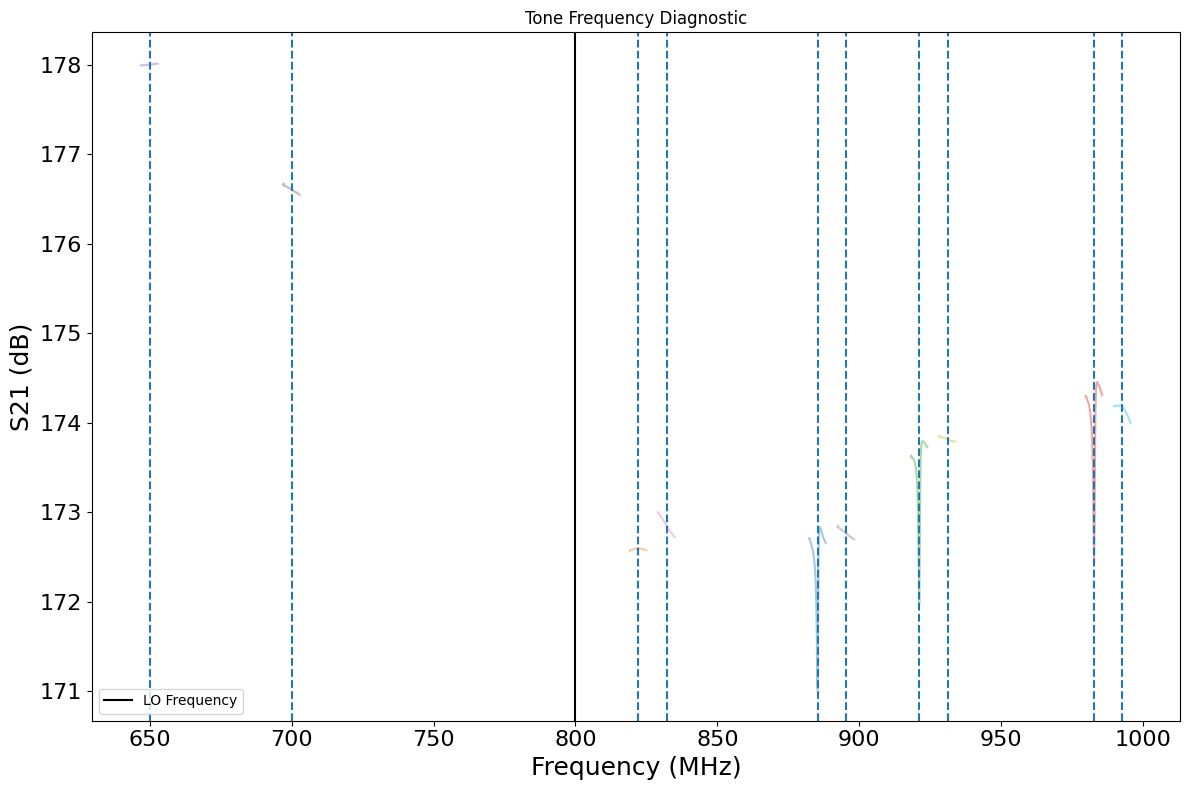

In [993]:
plt.figure(figsize=(12,8))

for i in range(len(target_sweep_S21[:,0])):
    freqs_i = target_sweep_freqs[i,:]/1e6
    s21_i = target_sweep_S21[i,:]
    s21_i_sqrd = s21_i.real ** 2 + s21_i.imag ** 2
    s21_i_pow = 10 * np.log10(s21_i_sqrd)

    tone_freq_i_upconv = (true_bb[0][i] + lofreq*1e6)/1e6
    
    plt.plot(freqs_i, s21_i_pow, alpha = 0.4)
    plt.axvline(x = tone_freq_i_upconv, linestyle = 'dashed')

plt.axvline(x = lofreq, color = 'black', linestyle = 'solid', label = 'LO Frequency')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Frequency (MHz)", fontsize=18)
plt.ylabel("S21 (dB)", fontsize=18)
plt.title("Tone Frequency Diagnostic")
plt.legend()
plt.tight_layout()

path = "/data/TKID_Readout_Plots_12012025/" + bath_temperature_reading
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)
    
filename = path + '/Target_Sweep_' + bath_temperature_reading
plt.savefig(filename)

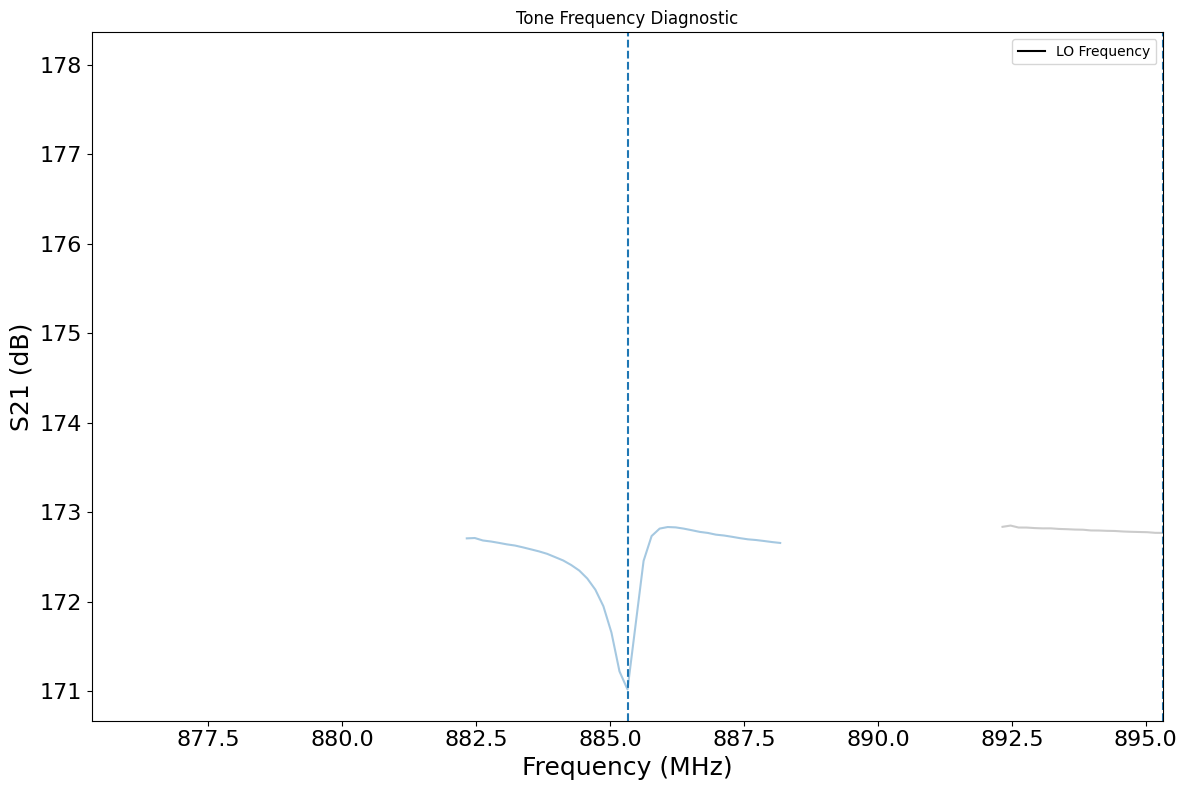

In [994]:
plt.figure(figsize=(12,8))

for i in range(len(target_sweep_S21[:,0])):
    freqs_i = target_sweep_freqs[i,:]/1e6
    s21_i = target_sweep_S21[i,:]
    s21_i_sqrd = s21_i.real ** 2 + s21_i.imag ** 2
    s21_i_pow = 10 * np.log10(s21_i_sqrd)

    tone_freq_i_upconv = (true_bb[0][i] + lofreq*1e6)/1e6
    
    plt.plot(freqs_i, s21_i_pow, alpha = 0.4)
    plt.axvline(x = tone_freq_i_upconv, linestyle = 'dashed')

x_res2_lower = (true_bb[0][0] + lofreq*1e6)/1e6 - 10
x_res2_upper = (true_bb[0][0] + lofreq*1e6)/1e6 + 10

plt.axvline(x = lofreq, color = 'black', linestyle = 'solid', label = 'LO Frequency')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlim(x_res2_lower, x_res2_upper)
plt.xlabel("Frequency (MHz)", fontsize=18)
plt.ylabel("S21 (dB)", fontsize=18)
plt.title("Tone Frequency Diagnostic")
plt.legend()
plt.tight_layout()

path = "/data/TKID_Readout_Plots_12012025/" + bath_temperature_reading
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)
    
filename = path + '/Active_Target_Sweep_' + bath_temperature_reading
plt.savefig(filename)

In [995]:
# Save the upconverted frequencies and baseband frequencies for data logging

path = "/data/TKID_Time_Constant_And_Noise_Sweeps_Tones_12012025/" + bath_temperature_reading
isExist = os.path.exists(path)
if not isExist:
    os.makedirs(path)
    
upfreqs_filename = path + '/rfsoc_upconv_freqs_' + bath_temperature_reading
bbfreqs_filename = path + '/rfsoc_baseband_freqs_' + bath_temperature_reading

upconv_freqs = np.array(downconv_freqs) + lofreq*1e6

np.save(upfreqs_filename, upconv_freqs)
np.save(bbfreqs_filename, downconv_freqs)

In [996]:
plt.close('all')